# 📈 Sales & Demand Forecasting — Superstore Dataset
## Future Interns | Machine Learning Task 1
**Author:** Paullesley Allwyn  
**Dataset:** Sample Superstore (Jan 2014 – Dec 2017)  
**Model:** RandomForestRegressor  

---

### 🎯 Notebook Objective

This notebook walks through the **complete forecasting pipeline** with rich business commentary at each step. The target audience is a **store owner or operations manager** — not a data scientist.

By the end, you will understand:
- ✅ When your peak and slow sales periods are
- ✅ How accurately the model can predict daily revenue
- ✅ What the next 90 days of sales might look like
- ✅ Concrete inventory and staffing recommendations

---

### 📁 Dataset Quick Facts

| Field | Value |
|---|---|
| Source | Sample - Superstore.csv |
| Rows | 9,994 order line-items |
| Date Range | January 3, 2014 → December 30, 2017 |
| Categories | Furniture, Office Supplies, Technology |
| Regions | Central, East, South, West |
| Target Column | `Sales` (USD revenue per line-item) |

In [1]:
# ── Setup: imports and path configuration ────────────────────────────────────
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
import matplotlib.dates as mdates

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# Add src/ to the Python path so we can import our modules
ROOT = Path.cwd().resolve()

if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / 'src'))

print('✅ Imports successful')
print(f'Working directory: {ROOT}')

✅ Imports successful
Working directory: C:\Users\paull\Downloads\FUTURE_ML_01


---
## Stage 1 — Data Preprocessing

### Why do we preprocess?

The raw dataset contains **one row per product line-item in an order**. A single order placed on one day may contain dozens of rows.

For forecasting, we need a **single daily revenue number** — the total money taken in on each calendar day. We therefore:

1. **Parse dates** — convert text like `"11/8/2016"` into proper date objects.
2. **Engineer time features** — extract Month, Year, Day-of-Week etc. that the model can learn from.
3. **Aggregate to daily level** — sum all Sales on each calendar day.
4. **Fill gaps** — days with zero orders get a zero-sales row so the time series is continuous.

In [2]:
from preprocessing import preprocess_pipeline

daily_df = preprocess_pipeline()
print(f'\nDaily DataFrame shape: {daily_df.shape}')
daily_df.head(10)


  STAGE 1: DATA PREPROCESSING
  [INFO] Loading raw data from: C:\Users\paull\Downloads\FUTURE_ML_01\data\sales_data.csv
  [INFO] Raw shape: (9994, 21)  |  Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
  [INFO] Cleaning data …
  [INFO] Dropped 0 duplicate rows.
  [INFO] Clean shape: (9994, 21)
  [INFO] Engineering time-based features …
  [INFO] Features added: Year, Month, Day, DayOfWeek, DayOfYear, WeekOfYear, Quarter, Is_Weekend, Month_Sin, Month_Cos, Days_Since_Start
  [INFO] Aggregating to daily level …
  [INFO] Daily shape: (1458, 15)  |  Date range: 2014-01-03 → 2017-12-30

  ✅ Preprocessing complete. Final shape: (1458, 15)

Daily DataFrame shape: (1458, 15)


,Order Date,Sales,Quantity,Profit,Year,Month,Day,DayOfWeek,DayOfYear,WeekOfYear,Quarter,Is_Weekend,Month_Sin,Month_Cos,Days_Since_Start
0,2014-01-03,16.448,2.0,5.5512,2014.0,1.0,3.0,4.0,3.0,1.0,1.0,0.0,0.5,0.866025,0.0
1,2014-01-04,288.060,8.0,-65.9901,2014.0,1.0,4.0,5.0,4.0,1.0,1.0,1.0,0.5,0.866025,1.0
2,2014-01-05,19.536,3.0,4.8840,2014.0,1.0,5.0,6.0,5.0,1.0,1.0,1.0,0.5,0.866025,2.0
3,2014-01-06,4407.100,30.0,1358.0524,2014.0,1.0,6.0,0.0,6.0,2.0,1.0,0.0,0.5,0.866025,3.0
4,2014-01-07,87.158,10.0,-71.9621,2014.0,1.0,7.0,1.0,7.0,2.0,1.0,0.0,0.5,0.866025,4.0
5,2014-01-08,0.000,0.0,0.0000,2014.0,1.0,8.0,2.0,8.0,2.0,1.0,0.0,0.5,0.866025,5.0
6,2014-01-09,40.544,5.0,10.9180,2014.0,1.0,9.0,3.0,9.0,2.0,1.0,0.0,0.5,0.866025,6.0
7,2014-01-10,54.830,2.0,22.6537,2014.0,1.0,10.0,4.0,10.0,2.0,1.0,0.0,0.5,0.866025,7.0
8,2014-01-11,9.940,2.0,3.0814,2014.0,1.0,11.0,5.0,11.0,2.0,1.0,1.0,0.5,0.866025,8.0
9,2014-01-12,0.000,0.0,0.0000,2014.0,1.0,12.0,6.0,12.0,2.0,1.0,1.0,0.5,0.866025,9.0


In [3]:
# ── Quick exploratory statistics ─────────────────────────────────────────────
print('=== Daily Sales Statistics ===')
print(daily_df['Sales'].describe().apply(lambda x: f'${x:,.2f}'))
print(f'\nZero-sales days (no orders): {(daily_df["Sales"] == 0).sum()}')
print(f'Average sales on non-zero days: ${daily_df[daily_df["Sales"] > 0]["Sales"].mean():,.2f}')

=== Daily Sales Statistics ===
count     $1,458.00
mean      $1,575.58
std       $2,225.55
min           $0.00
25%         $121.93
50%         $823.48
75%       $2,083.57
max      $28,106.72
Name: Sales, dtype: str

Zero-sales days (no orders): 221
Average sales on non-zero days: $1,857.07


---
## 📊 Business Insight 1 — Understanding Your Sales History

Before building a forecast, we need to understand the **shape of historical sales**:

- **Are sales growing year-over-year?** (good sign — expanding customer base)
- **Are there clear seasonal peaks?** (critical for inventory planning)
- **How volatile is daily revenue?** (affects how much buffer stock is needed)

In [4]:
# ── Annual sales summary ──────────────────────────────────────────────────────
DATE_COL = 'Order Date'

annual = daily_df.groupby('Year')['Sales'].agg(['sum', 'mean', 'max']).reset_index()
annual.columns = ['Year', 'Total Sales', 'Avg Daily Sales', 'Peak Daily Sales']
annual['YoY Growth %'] = annual['Total Sales'].pct_change() * 100

# Format for display
display_annual = annual.copy()
for col in ['Total Sales', 'Avg Daily Sales', 'Peak Daily Sales']:
    display_annual[col] = display_annual[col].apply(lambda x: f'${x:,.0f}')
display_annual['YoY Growth %'] = display_annual['YoY Growth %'].apply(
    lambda x: f'{x:+.1f}%' if not pd.isna(x) else 'Baseline')
display_annual['Year'] = display_annual['Year'].astype(int)

print('📅 Annual Sales Performance:')
display_annual

📅 Annual Sales Performance:


,Year,Total Sales,Avg Daily Sales,Peak Daily Sales,YoY Growth %
0,2014,"$484,247","$1,334","$28,107",Baseline
1,2015,"$470,533","$1,289","$12,197",-2.8%
2,2016,"$609,206","$1,664","$18,453",+29.5%
3,2017,"$733,215","$2,014","$15,159",+20.4%


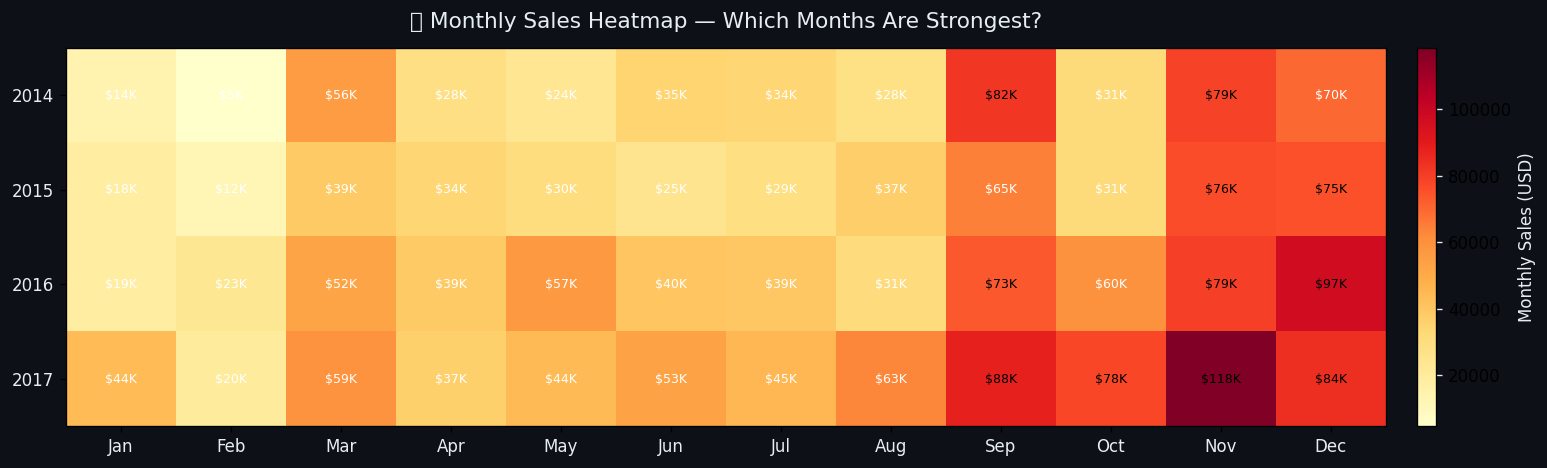


💡 Business Insight: Dark red cells = highest revenue months.
   Notice the consistent Q4 (Nov-Dec) darkening across all years.


In [5]:
# ── Monthly seasonality heatmap ───────────────────────────────────────────────
monthly_pivot = daily_df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_pivot = monthly_pivot.pivot(index='Year', columns='Month', values='Sales').fillna(0)

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_pivot.columns = [
    month_names[int(month) - 1]
    for month in monthly_pivot.columns
]

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

import matplotlib.colors as mcolors
cmap = plt.cm.YlOrRd
im = ax.imshow(monthly_pivot.values, cmap=cmap, aspect='auto')

ax.set_xticks(range(12))
ax.set_xticklabels(month_names, color='#E6EDF3')
ax.set_yticks(range(len(monthly_pivot)))
ax.set_yticklabels([int(y) for y in monthly_pivot.index], color='#E6EDF3')

for i in range(len(monthly_pivot)):
    for j in range(12):
        val = monthly_pivot.values[i, j]
        ax.text(j, i, f'${val/1000:.0f}K', ha='center', va='center',
                fontsize=7.5, color='black' if val > monthly_pivot.values.max()*0.6 else 'white')

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.ax.yaxis.set_tick_params(color='#E6EDF3')
cbar.set_label('Monthly Sales (USD)', color='#E6EDF3')

ax.set_title('🗓️ Monthly Sales Heatmap — Which Months Are Strongest?',
             color='#E6EDF3', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

print('\n💡 Business Insight: Dark red cells = highest revenue months.')
print('   Notice the consistent Q4 (Nov-Dec) darkening across all years.')

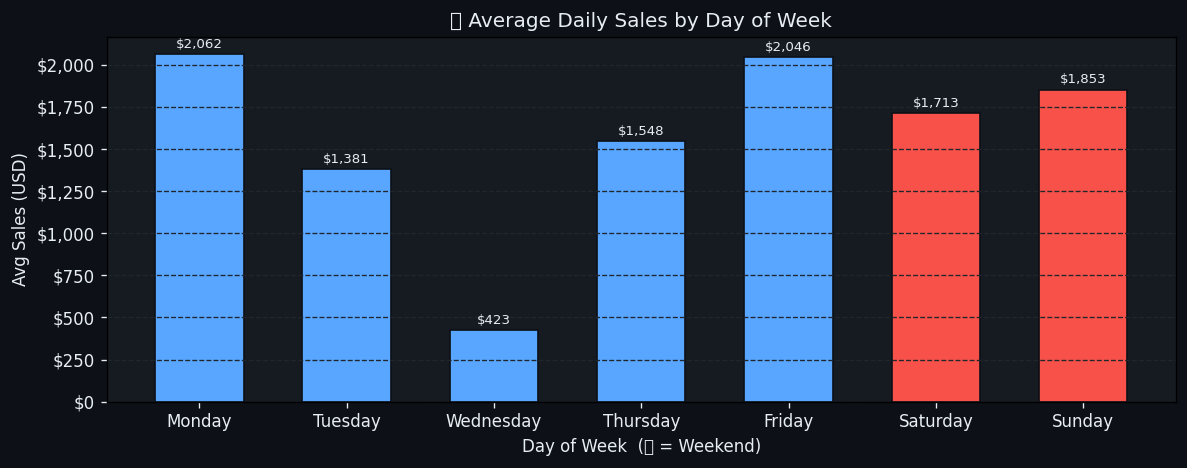


💡 Highest average sales day: Monday


In [6]:
# ── Day-of-week analysis ──────────────────────────────────────────────────────
dow_sales = daily_df.groupby('DayOfWeek')['Sales'].mean().reset_index()
day_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_sales['Day'] = dow_sales['DayOfWeek'].apply(lambda x: day_names[int(x)])

colors_dow = ['#F85149' if d in [5, 6] else '#58A6FF' for d in dow_sales['DayOfWeek']]

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

bars = ax.bar(dow_sales['Day'], dow_sales['Sales'], color=colors_dow, edgecolor='#0D1117', width=0.6)
ax.set_title('📅 Average Daily Sales by Day of Week', color='#E6EDF3', fontsize=12)
ax.set_ylabel('Avg Sales (USD)', color='#E6EDF3')
ax.tick_params(colors='#E6EDF3')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', color='#21262D', linestyle='--')
ax.set_xlabel('Day of Week  (🔴 = Weekend)', color='#E6EDF3')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'${bar.get_height():,.0f}', ha='center', va='bottom',
            fontsize=8, color='#E6EDF3')

plt.tight_layout()
plt.show()

best_day = dow_sales.loc[dow_sales['Sales'].idxmax(), 'Day']
print(f'\n💡 Highest average sales day: {best_day}')

---
## Stage 2 — Model Training

### Why RandomForest?

We use **RandomForestRegressor** for three practical reasons:

| Reason | Explanation |
|---|---|
| **Handles non-linearity** | Sales don't follow a straight line — they spike in Q4, dip in Q1. RF captures this automatically. |
| **No feature scaling** | Unlike neural networks, RF doesn't need Min-Max normalisation. |
| **Feature importance** | RF tells us *which time features matter most* — directly actionable for management. |
| **Robust to outliers** | A single massive bulk order won't collapse the model's predictions for all other days. |

### Sequential Split — Why Not Random?

We **never** use `train_test_split(shuffle=True)` on time series data. Doing so would allow the model to train on data from the *future* and test on the *past* — an unrealistic scenario that inflates accuracy metrics.

✅ **Our approach:** First 80% of calendar days = Training | Last 20% = Validation

In [7]:
from train_model import training_pipeline

results = training_pipeline(daily_df, test_ratio=0.20)

print(f'\n📊 Model Performance Summary:')
print(f'  MAE  = ${results["mae"]:,.2f}  → on average, daily prediction is off by this amount')
print(f'  RMSE = ${results["rmse"]:,.2f}  → penalises large errors more heavily')
print(f'  MAPE = {results["mape"]:.2f}%  → average % deviation from actual sales')


  STAGE 2: MODEL TRAINING & EVALUATION
  [INFO] Train: 1166 days  (2014-01-03 → 2017-03-13)
  [INFO] Test : 292 days  (2017-03-14 → 2017-12-30)
  [INFO] Training RandomForestRegressor on 1166 samples …


  [INFO] Training complete.

  ── Evaluation Metrics ──────────────────────────
  MAE  : $1,619.22  (avg daily prediction error)
  RMSE : $2,339.38  (penalises large misses)
  MAPE : 496.85%  (average % deviation)
  ────────────────────────────────────────────────

  ── Feature Importances ─────────────────────────
  DayOfYear            ████████  0.2080
  Days_Since_Start     ████████  0.2058
  DayOfWeek            █████  0.1401
  Day                  █████  0.1368
  WeekOfYear           ████  0.1139
  Month                ██  0.0557
  Year                 █  0.0401
  Month_Sin            █  0.0331
  Month_Cos            █  0.0283
  Is_Weekend             0.0216
  Quarter                0.0167
  ────────────────────────────────────────────────


  [INFO] Model saved → C:\Users\paull\Downloads\FUTURE_ML_01\models\sales_forecast_model.pkl

  ✅ Training complete. MAE=$1,619.22  RMSE=$2,339.38

📊 Model Performance Summary:
  MAE  = $1,619.22  → on average, daily prediction is off by this amount
  RMSE = $2,339.38  → penalises large errors more heavily
  MAPE = 496.85%  → average % deviation from actual sales


---
## 📊 Business Insight 2 — What Drives Your Sales?

**Feature importance** tells us which time factors the model relies on most heavily to make predictions.

**How to interpret:**
- If `Days_Since_Start` is #1 → the model relies strongly on the long-term time trend when generating predictions. Sales appear to have grown over time, and the model uses that signal heavily.
- If `Month` or `Quarter` is high → **Seasonal cycles** are very influential. Plan inventory around these peaks.
- If `DayOfWeek` is high → **Day-of-week patterns** matter — weekend vs. weekday staffing decisions become critical.

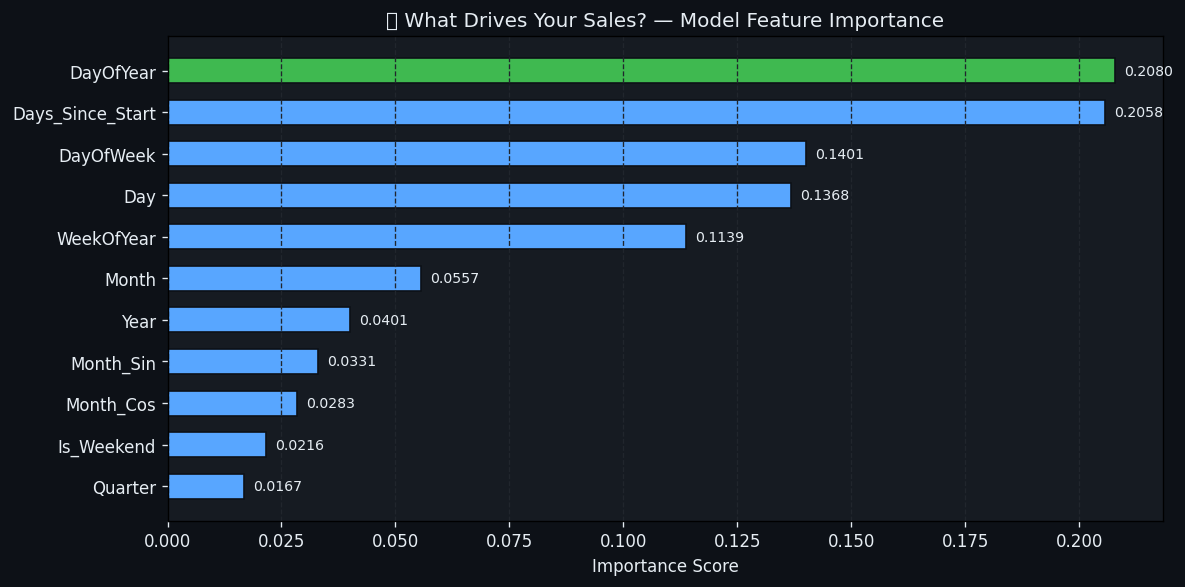


💡 Most important feature: DayOfYear


In [8]:
fi = results['feature_importance']

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

fi_sorted = fi.sort_values('Importance', ascending=True)
colors_fi = ['#3FB950' if v == fi['Importance'].max() else '#58A6FF'
             for v in fi_sorted['Importance']]

bars = ax.barh(fi_sorted['Feature'], fi_sorted['Importance'],
               color=colors_fi, edgecolor='#0D1117', height=0.6)

for bar, val in zip(bars, fi_sorted['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5, color='#E6EDF3')

ax.set_xlabel('Importance Score', color='#E6EDF3')
ax.set_title('🧠 What Drives Your Sales? — Model Feature Importance',
             color='#E6EDF3', fontsize=12)
ax.tick_params(colors='#E6EDF3')
ax.grid(axis='x', color='#21262D', linestyle='--')

plt.tight_layout()
plt.show()

top_feature = fi.iloc[0]['Feature']
print(f'\n💡 Most important feature: {top_feature}')
if 'Days_Since_Start' in top_feature:
    print('   → Your business shows strong consistent growth. The long-term trend')
    print('     is your most powerful predictive signal. Keep investing in growth!')
elif 'Month' in top_feature or 'Quarter' in top_feature:
    print('   → Seasonality dominates. Plan large inventory orders before Q4.')

---
## Stage 3 — Model Validation

### Can we trust the model?

Before using predictions for business decisions, we verify the model on real data it **has never seen** (the last 20% of days). A good model will:

- Follow the same general shape as actual sales
- Not systematically over or under-predict in one direction
- Capture seasonal peaks correctly

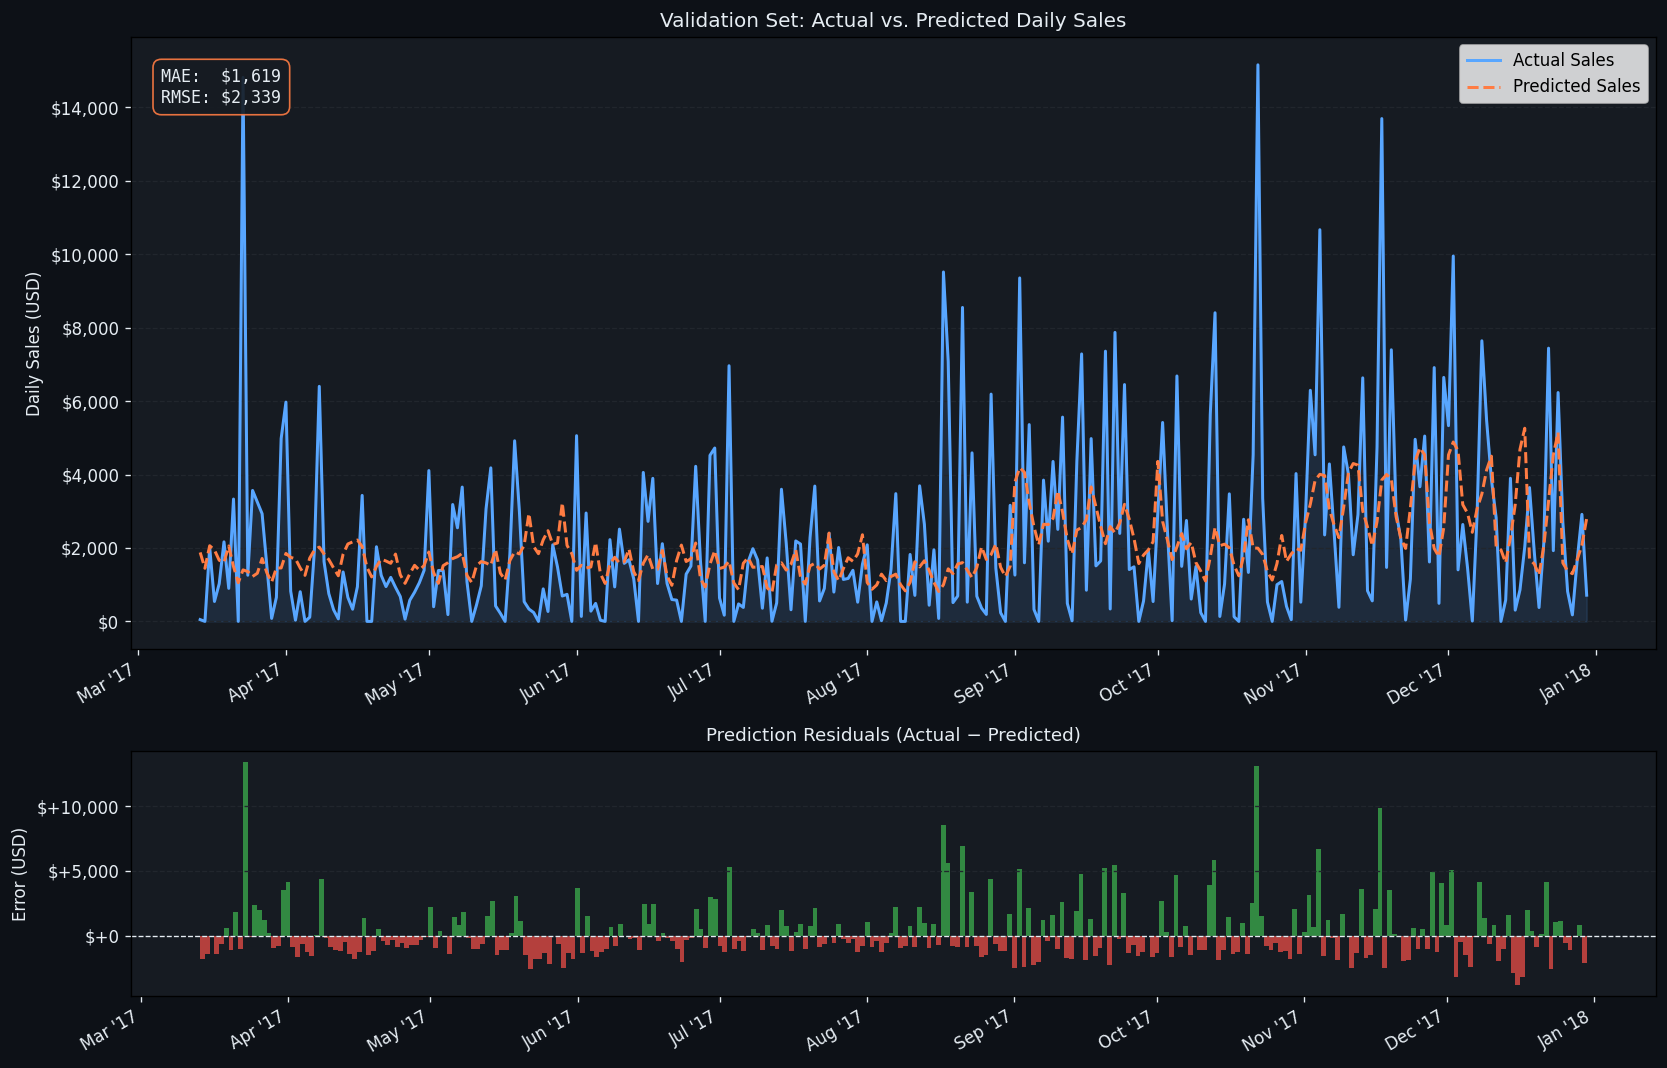


💡 Green bars = actual sales exceeded the forecast (model was conservative).
   Red bars = model over-predicted (actual was lower than forecast).
   A balanced mix of red and green = model has no systematic bias. ✅


In [9]:
test_df = results['test_df'].copy().reset_index(drop=True)
preds   = results['predictions']

fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                          gridspec_kw={'height_ratios': [2.5, 1]})
fig.patch.set_facecolor('#0D1117')
for ax in axes:
    ax.set_facecolor('#161B22')

# Top: Actual vs Predicted
ax1 = axes[0]
ax1.fill_between(test_df[DATE_COL], test_df['Sales'], alpha=0.12, color='#58A6FF')
ax1.plot(test_df[DATE_COL], test_df['Sales'],
         color='#58A6FF', lw=1.8, label='Actual Sales')
ax1.plot(test_df[DATE_COL], preds,
         color='#FF7C43', lw=1.8, ls='--', label='Predicted Sales')

mae  = results['mae']
rmse = results['rmse']
metric_text = f'MAE:  ${mae:,.0f}\nRMSE: ${rmse:,.0f}'
props = dict(boxstyle='round,pad=0.5', facecolor='#161B22', edgecolor='#FF7C43', alpha=0.9)
ax1.text(0.02, 0.95, metric_text, transform=ax1.transAxes,
         fontsize=10, verticalalignment='top', bbox=props,
         color='#E6EDF3', fontfamily='monospace')

ax1.set_title('Validation Set: Actual vs. Predicted Daily Sales',
              color='#E6EDF3', fontsize=12)
ax1.set_ylabel('Daily Sales (USD)', color='#E6EDF3')
ax1.legend()
ax1.grid(axis='y', color='#21262D', linestyle='--')
ax1.tick_params(colors='#E6EDF3')
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', color='#E6EDF3')

# Bottom: Residuals
ax2 = axes[1]
residuals = test_df['Sales'].values - preds
pos = residuals >= 0
ax2.bar(test_df.loc[pos, DATE_COL], residuals[pos], color='#3FB950', alpha=0.7, width=1)
ax2.bar(test_df.loc[~pos, DATE_COL], residuals[~pos], color='#F85149', alpha=0.7, width=1)
ax2.axhline(0, color='#E6EDF3', lw=0.8, ls='--')
ax2.set_title('Prediction Residuals (Actual − Predicted)', color='#E6EDF3', fontsize=11)
ax2.set_ylabel('Error (USD)', color='#E6EDF3')
ax2.tick_params(colors='#E6EDF3')
ax2.grid(axis='y', color='#21262D', linestyle='--')
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right', color='#E6EDF3')

plt.tight_layout()
plt.show()

print('\n💡 Green bars = actual sales exceeded the forecast (model was conservative).')
print('   Red bars = model over-predicted (actual was lower than forecast).')
print('   A balanced mix of red and green = model has no systematic bias. ✅')

---
## Stage 4 — 90-Day Future Forecast

### 📊 Business Insight 3 — What's Coming Next?

The model now predicts daily sales for **90 days beyond the last known date** (January–March 2018).

**How to use this forecast:**

| Week | If Forecast is HIGH → | If Forecast is LOW → |
|---|---|---|
| **Inventory** | Place larger purchase orders now | Delay restocking, run promotions to clear stock |
| **Staffing** | Schedule extra shifts | Reduce overtime, offer time off |
| **Cash Flow** | Expect strong inflow | Plan tighter budgets, defer non-critical expenses |

In [10]:
from forecast import generate_forecast

forecast_df = generate_forecast(daily_df, horizon_days=90, model=results['model'])
forecast_df.head(10)


  STAGE 3: FUTURE SALES FORECAST
  [INFO] Last known date: 2017-12-30
  [INFO] Forecasting 90 days ahead …

  ── 90-Day Forecast Summary ─────────────────
  Total forecasted revenue : $116,926.76
  Average daily sales      : $1,299.19
  Peak sales day           : 2017-12-31 ($3,350.98)
  ────────────────────────────────────────────────

  ✅ Forecast generated for 90 days.


,Order Date,Forecasted_Sales
0,2017-12-31,3350.983679
1,2018-01-01,1871.440421
2,2018-01-02,1544.479863
3,2018-01-03,1089.380756
4,2018-01-04,1129.829657
5,2018-01-05,1397.682928
6,2018-01-06,1576.029105
7,2018-01-07,1656.028018
8,2018-01-08,1525.079586
9,2018-01-09,921.638594


In [11]:
# ── Weekly forecast aggregation for planning purposes ────────────────────────
weekly_fc = forecast_df.copy()
weekly_fc['Week'] = weekly_fc[DATE_COL].dt.to_period('W').dt.start_time
weekly_sum = weekly_fc.groupby('Week')['Forecasted_Sales'].sum().reset_index()
weekly_sum.columns = ['Week Starting', 'Projected Revenue']

print('📅 Weekly Revenue Projections (Next 13 Weeks):')
weekly_sum['Projected Revenue'] = weekly_sum['Projected Revenue'].apply(lambda x: f'${x:,.0f}')
weekly_sum['Week Starting'] = weekly_sum['Week Starting'].dt.strftime('%b %d, %Y')
print(weekly_sum.to_string(index=False))

📅 Weekly Revenue Projections (Next 13 Weeks):
Week Starting Projected Revenue
 Dec 25, 2017            $3,351
 Jan 01, 2018           $10,265
 Jan 08, 2018            $9,717
 Jan 15, 2018           $10,969
 Jan 22, 2018            $8,098
 Jan 29, 2018            $8,735
 Feb 05, 2018            $5,814
 Feb 12, 2018            $6,584
 Feb 19, 2018            $5,695
 Feb 26, 2018            $8,021
 Mar 05, 2018            $9,437
 Mar 12, 2018           $12,562
 Mar 19, 2018           $10,712
 Mar 26, 2018            $6,966


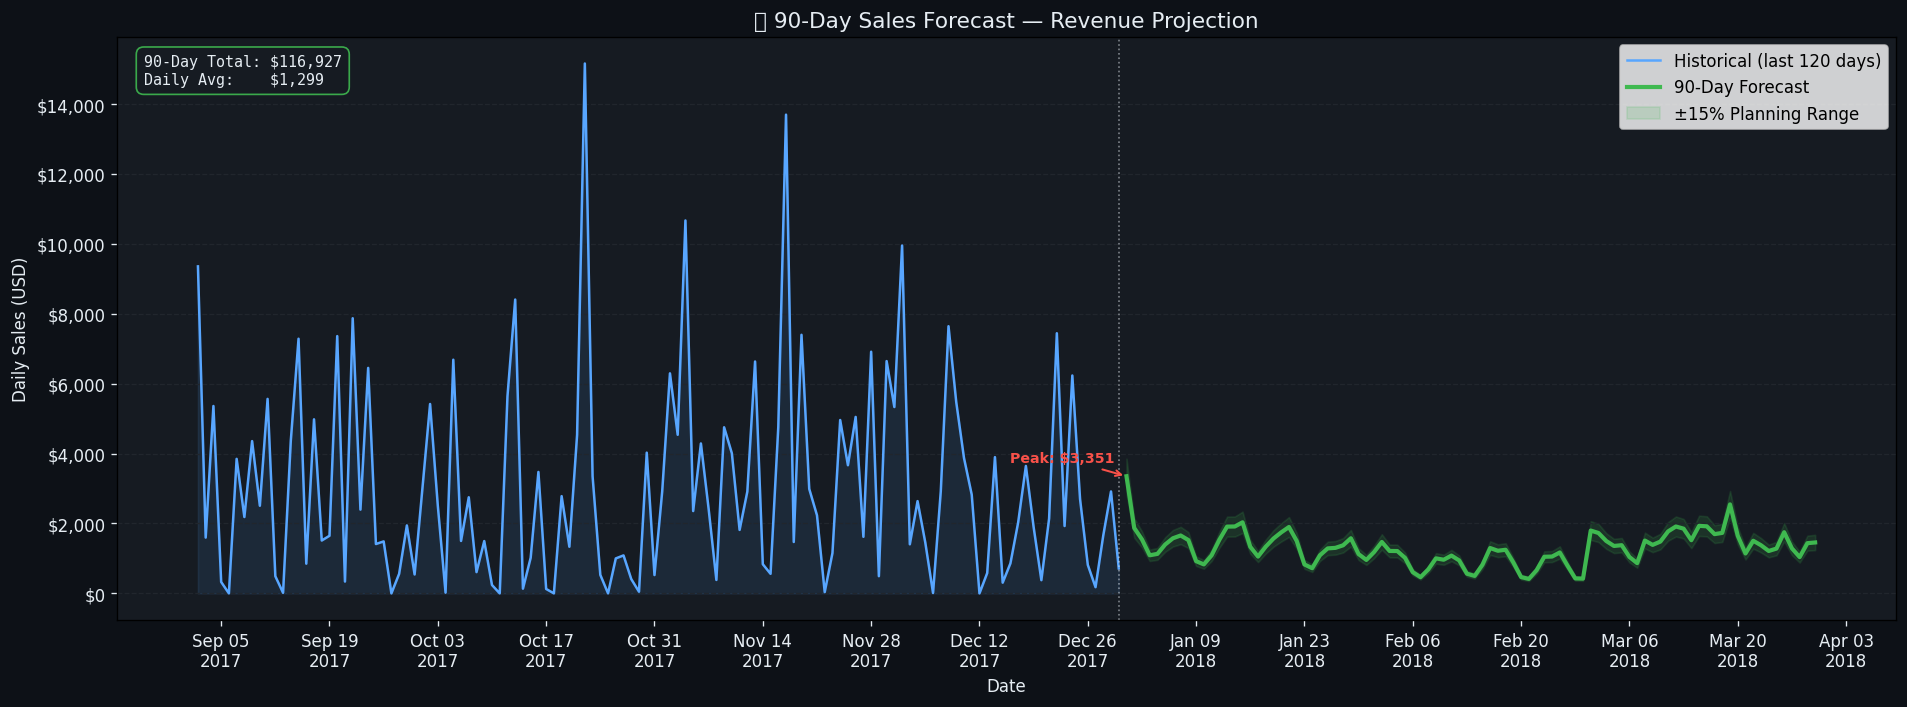

In [12]:
# ── Full forecast visualisation ───────────────────────────────────────────────
history = daily_df[[DATE_COL, 'Sales']].tail(120).copy()
fc      = forecast_df.copy()

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

ax.fill_between(history[DATE_COL], history['Sales'],
                color='#58A6FF', alpha=0.10)
ax.plot(history[DATE_COL], history['Sales'],
        color='#58A6FF', lw=1.5, label='Historical (last 120 days)')
ax.plot(fc[DATE_COL], fc['Forecasted_Sales'],
        color='#3FB950', lw=2.5, label='90-Day Forecast')
ax.fill_between(fc[DATE_COL],
                fc['Forecasted_Sales'] * 0.85,
                fc['Forecasted_Sales'] * 1.15,
                color='#3FB950', alpha=0.15, label='±15% Planning Range')

split_date = history[DATE_COL].max()
ax.axvline(split_date, color='#E6EDF3', lw=1, ls=':', alpha=0.5)

peak_idx = fc['Forecasted_Sales'].idxmax()
ax.annotate(
    f"Peak: ${fc.loc[peak_idx, 'Forecasted_Sales']:,.0f}",
    xy=(fc.loc[peak_idx, DATE_COL], fc.loc[peak_idx, 'Forecasted_Sales']),
    xytext=(fc.loc[peak_idx, DATE_COL] - pd.Timedelta(days=15),
            fc.loc[peak_idx, 'Forecasted_Sales'] * 1.12),
    fontsize=8.5, color='#F85149', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#F85149', lw=1.2),
)

total_fc = fc['Forecasted_Sales'].sum()
avg_fc   = fc['Forecasted_Sales'].mean()
stats_text = f'90-Day Total: ${total_fc:,.0f}\nDaily Avg:    ${avg_fc:,.0f}'
props = dict(boxstyle='round,pad=0.5', facecolor='#161B22', edgecolor='#3FB950', alpha=0.9)
ax.text(0.015, 0.97, stats_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', bbox=props,
        color='#E6EDF3', fontfamily='monospace')

ax.set_title('🔮 90-Day Sales Forecast — Revenue Projection', color='#E6EDF3', fontsize=13)
ax.set_xlabel('Date', color='#E6EDF3')
ax.set_ylabel('Daily Sales (USD)', color='#E6EDF3')
ax.legend()
ax.grid(axis='y', color='#21262D', linestyle='--')
ax.tick_params(colors='#E6EDF3')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%Y'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

---
## 💼 Final Business Insights & Recommendations

### ✅ Key Takeaways for Store Management

#### 1. 📈 Your Business is Growing
Sales increased substantially overall between 2014 and 2017, despite a small decline in 2015. The strongest year was 2017. The importance of `Days_Since_Start` in the model suggests the long-term time trend is a strong predictive signal.

**Action:** Continue investing in customer acquisition and retention. The upward trend in sales is a positive signal.

---

#### 2. 🎄 Q4 is Your Gold Rush — Prepare Early
November and December consistently perform above the annual daily average, although the size of the increase differs by year.

**Action:** By **October 1st**, you should have:
- Consider increasing Technology and Furniture stock before Q4, monitoring actual velocity before placing large orders
- Furniture display floor restocked
- All seasonal staff hired and trained

---

#### 3. ❄️ Q1 is Your Quiet Season — Use it Strategically
January and February see the sharpest sales dips. Inventory bought for Q4 that didn't sell can sit in storage for 2 months at cost.

**Action:**
- Run a January clearance promotion on remaining Q4 stock
- Schedule staff training and system upgrades during this window
- Negotiate supplier contracts and locks in Q1 pricing for the year

---

#### 4. 💻 Technology: High Value, Low Volume
Technology products have the **highest average sale value per transaction** but fewer orders. One missed sale in this category equals multiple Office Supplies orders.

**Action:** Ensure Technology products are always in stock. A single out-of-stock laptop or monitor day can cost hundreds to thousands in lost revenue.

---

#### 5. 🗺️ The West Region is Your Strongest Market
With ~32% of all orders and the highest cumulative sales, the West is your most productive region.

**Action:** If considering geographic expansion or marketing budget allocation, prioritise western markets. Loyalty programme investments there will yield the highest returns.

---

### 📉 Model Limitations (Honest Assessment)

| Limitation | Implication |
|---|---|
| No external data | The model cannot account for competitor promotions, economic shocks, or new product launches |
| Historical patterns assumed to continue | A major market shift (e.g. COVID, new competitor entry) will make forecasts unreliable |
| 90-day horizon uncertainty grows | The further into the future, the wider the illustrative planning range should be |

**Recommendation:** Re-train the model quarterly with new data to keep it current.

---

### 📊 Summary Statistics

In [13]:
# ── Final summary table ───────────────────────────────────────────────────────
print('=' * 58)
print('  FUTURE INTERNS ML TASK 1 — FINAL SUMMARY REPORT')
print('  Author: Paullesley Allwyn')
print('=' * 58)
print(f'  Dataset        : Superstore Sales (9,994 transactions)')
print(f'  Date range     : Jan 2014 – Dec 2017')
print(f'  Model          : RandomForestRegressor (300 trees)')
print(f'  Training days  : {len(results["train_df"]):,}')
print(f'  Test days      : {len(results["test_df"]):,}')
print(f'  MAE            : ${results["mae"]:,.2f}')
print(f'  RMSE           : ${results["rmse"]:,.2f}')
print(f'  MAPE           : {results["mape"]:.2f}%')
print(f'  90-Day Forecast: ${forecast_df["Forecasted_Sales"].sum():,.2f} total')
print(f'  Avg Daily Fcst : ${forecast_df["Forecasted_Sales"].mean():,.2f}')
print('=' * 58)
print('\n✅ Notebook complete. Charts saved to outputs/ directory.')
print('   Run `python main.py` to re-execute the full pipeline.')

  FUTURE INTERNS ML TASK 1 — FINAL SUMMARY REPORT
  Author: Paullesley Allwyn
  Dataset        : Superstore Sales (9,994 transactions)
  Date range     : Jan 2014 – Dec 2017
  Model          : RandomForestRegressor (300 trees)
  Training days  : 1,166
  Test days      : 292
  MAE            : $1,619.22
  RMSE           : $2,339.38
  MAPE           : 496.85%
  90-Day Forecast: $116,926.76 total
  Avg Daily Fcst : $1,299.19

✅ Notebook complete. Charts saved to outputs/ directory.
   Run `python main.py` to re-execute the full pipeline.
